In [3]:
%pip install -q tqdm torchmetrics optuna
%matplotlib inline

import sys
import random
from pathlib import Path
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms as T
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import optuna

# Relative paths (run this script from student_start_pack/)
if "__file__" in globals():
    FILE_DIR = Path(__file__).resolve().parent
else:
    FILE_DIR = Path.cwd()

PROJECT_ROOT = FILE_DIR.parent
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from artbench_local_dataset import load_kaggle_artbench10_splits


import requests, traceback

def notify(msg, title="Notebook"):
    requests.post("https://ntfy.sh/notebookIAGricardo",
        data=msg, headers={"Title": title, "Priority": "high"})




[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [4]:
class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

set_seed(42)
device = get_device()
print('Device:', device)

Device: cuda


In [5]:
def build_loaders(
    dataset_name='artbench',
    batch_size=128,
    train_limit=10000,
    test_limit=None,
    data_root='IAGdata/artbench-10-python',
    num_workers=0,
):
    image_size = 32
    channels = 3
    
    transform = T.Compose([
        T.Resize(image_size),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    
    hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
    train_ds = HFDatasetTorch(hf_ds["train"], transform=transform)
    test_ds = HFDatasetTorch(hf_ds["test"], transform=transform)
    class_names = hf_ds["train"].features["label"].names

    if train_limit is not None:
        train_ds = Subset(train_ds, list(range(min(train_limit, len(train_ds)))))
    if test_limit is not None:
        test_ds = Subset(test_ds, list(range(min(test_limit, len(test_ds)))))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader, channels, image_size, class_names

def denorm(x):
    return (x + 1.0) / 2.0

def show_image_grid(images, channels=3, title='Images', n_show=25):
    images = images[:n_show].detach().cpu()
    images = denorm(images).clamp(0, 1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(grid * 1.6, grid * 1.6))
    axes = np.atleast_2d(axes)

    idx = 0
    for i in range(grid):
        for j in range(grid):
            ax = axes[i, j]
            ax.axis('off')
            if idx < n:
                ax.imshow(images[idx].permute(1, 2, 0))
            idx += 1
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### Diffusion Components

In [6]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

class GaussianDiffusion:
    def __init__(self, num_timesteps=1000, beta_schedule='cosine', beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        
        if beta_schedule == 'cosine':
            self.betas = cosine_beta_schedule(num_timesteps).to(device)
        else:
            self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.]).to(device), self.alphas_cumprod[:-1]])
        
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)

    def q_sample(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_alpha_prod = self._get_index(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alpha_prod = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
        return sqrt_alpha_prod * x_0 + sqrt_one_minus_alpha_prod * noise

    def _get_index(self, tensor, t, x_shape):
        out = tensor.gather(-1, t)
        return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))

    @torch.no_grad()
    def p_sample_loop(self, model, shape):
        model.eval()
        x = torch.randn(shape, device=self.device)
        for step in reversed(range(self.num_timesteps)):
            t = torch.full((shape[0],), step, device=self.device, dtype=torch.long)
            pred_noise = model(x, t)

            alpha_t = self.alphas[step]
            alpha_bar_t = self.alphas_cumprod[step]
            beta_t = self.betas[step]

            if step > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = (1.0 / torch.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * pred_noise) + torch.sqrt(beta_t) * noise
        return x

    @torch.no_grad()
    def ddim_sample_loop(self, model, shape, ddim_steps=100, eta=0.0, x_init=None):
        """DDIM sampling for faster inference (Song et al., 2020)"""
        model.eval()
        # Create sub-sequence of timesteps
        step_size = self.num_timesteps // ddim_steps
        timesteps = list(range(0, self.num_timesteps, step_size))
        timesteps = list(reversed(timesteps))
        
        x = x_init.clone() if x_init is not None else torch.randn(shape, device=self.device)
        
        for i in range(len(timesteps)):
            t_cur = timesteps[i]
            t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else 0
            
            t_batch = torch.full((shape[0],), t_cur, device=self.device, dtype=torch.long)
            pred_noise = model(x, t_batch)
            
            alpha_bar_t = self.alphas_cumprod[t_cur]
            alpha_bar_prev = self.alphas_cumprod[t_prev] if t_prev > 0 else torch.tensor(1.0, device=self.device)
            
            # Predict x_0
            pred_x0 = (x - torch.sqrt(1 - alpha_bar_t) * pred_noise) / torch.sqrt(alpha_bar_t)
            pred_x0 = pred_x0.clamp(-1, 1)
            
            # Compute variance
            sigma = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev))
            
            # Direction pointing to x_t
            dir_xt = torch.sqrt(1 - alpha_bar_prev - sigma ** 2) * pred_noise
            
            noise = torch.randn_like(x) if t_cur > 0 else torch.zeros_like(x)
            x = torch.sqrt(alpha_bar_prev) * pred_x0 + dir_xt + sigma * noise
        
        return x

In [7]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class SelfAttention(nn.Module):
    def __init__(self, dim, num_groups=32):
        super().__init__()
        self.norm = nn.GroupNorm(min(num_groups, dim), dim)
        self.qkv = nn.Conv2d(dim, dim * 3, 1)
        self.proj = nn.Conv2d(dim, dim, 1)
        self.scale = dim ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = (q.transpose(-1, -2) @ k) * self.scale
        attn = attn.softmax(dim=-1)
        out = (v @ attn.transpose(-1, -2)).reshape(B, C, H, W)
        return x + self.proj(out)

class ResnetBlock(nn.Module):
    def __init__(self, dim, time_emb_dim, out_dim=None, num_groups=32):
        super().__init__()
        self.out_dim = out_dim or dim
        self.mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, self.out_dim))
        self.conv1 = nn.Conv2d(dim, self.out_dim, 3, padding=1)
        self.conv2 = nn.Conv2d(self.out_dim, self.out_dim, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(num_groups, dim), dim)
        self.norm2 = nn.GroupNorm(min(num_groups, self.out_dim), self.out_dim)
        self.act = nn.SiLU()
        self.shortcut = nn.Conv2d(dim, self.out_dim, 1) if dim != self.out_dim else nn.Identity()

    def forward(self, x, time_emb):
        h = self.conv1(self.act(self.norm1(x)))
        h = h + self.mlp(time_emb)[:, :, None, None]
        h = self.conv2(self.act(self.norm2(h)))
        return self.shortcut(x) + h

class PixelUNet(nn.Module):
    def __init__(self, in_channels=3, model_channels=128, num_groups=32):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalPosEmb(model_channels),
            nn.Linear(model_channels, model_channels * 4),
            nn.SiLU(),
            nn.Linear(model_channels * 4, model_channels * 4),
        )
        time_dim = model_channels * 4
        self.init_conv = nn.Conv2d(in_channels, model_channels, 3, padding=1)
        
        # 32 -> 16
        self.down1_res1 = ResnetBlock(model_channels, time_dim, num_groups=num_groups)
        self.down1_res2 = ResnetBlock(model_channels, time_dim, num_groups=num_groups)
        self.down1_pool = nn.Conv2d(model_channels, model_channels, 3, stride=2, padding=1)
        
        # 16 -> 8 (with attention at 16x16)
        self.down2_res1 = ResnetBlock(model_channels, time_dim, out_dim=model_channels * 2, num_groups=num_groups)
        self.down2_attn = SelfAttention(model_channels * 2, num_groups=num_groups)
        self.down2_res2 = ResnetBlock(model_channels * 2, time_dim, num_groups=num_groups)
        self.down2_pool = nn.Conv2d(model_channels * 2, model_channels * 2, 3, stride=2, padding=1)
        
        # Bottleneck at 8x8 (with attention)
        self.mid_res1 = ResnetBlock(model_channels * 2, time_dim, num_groups=num_groups)
        self.mid_attn = SelfAttention(model_channels * 2, num_groups=num_groups)
        self.mid_res2 = ResnetBlock(model_channels * 2, time_dim, num_groups=num_groups)
        
        # 8 -> 16 (with attention)
        self.up2_upsample = nn.ConvTranspose2d(model_channels * 2, model_channels, 4, stride=2, padding=1)
        self.up2_res1 = ResnetBlock(model_channels * 3, time_dim, out_dim=model_channels, num_groups=num_groups)
        self.up2_attn = SelfAttention(model_channels, num_groups=num_groups)
        self.up2_res2 = ResnetBlock(model_channels, time_dim, num_groups=num_groups)
        
        # 16 -> 32
        self.up1_upsample = nn.ConvTranspose2d(model_channels, model_channels, 4, stride=2, padding=1)
        self.up1_res1 = ResnetBlock(model_channels * 2, time_dim, out_dim=model_channels, num_groups=num_groups)
        self.up1_res2 = ResnetBlock(model_channels, time_dim, num_groups=num_groups)
        
        self.out_norm = nn.GroupNorm(min(num_groups, model_channels), model_channels)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(model_channels, in_channels, 3, padding=1)
        
    def forward(self, x, t):
        t_emb = self.time_embed(t)
        
        h_init = self.init_conv(x)
        
        # Down 1: 32 -> 16
        h1 = self.down1_res1(h_init, t_emb)
        h1 = self.down1_res2(h1, t_emb)
        h1_pool = self.down1_pool(h1)
        
        # Down 2: 16 -> 8 (with attention)
        h2 = self.down2_res1(h1_pool, t_emb)
        h2 = self.down2_attn(h2)
        h2 = self.down2_res2(h2, t_emb)
        h2_pool = self.down2_pool(h2)
        
        # Bottleneck at 8x8
        h_mid = self.mid_res1(h2_pool, t_emb)
        h_mid = self.mid_attn(h_mid)
        h_mid = self.mid_res2(h_mid, t_emb)
        
        # Up 2: 8 -> 16
        h_up2 = torch.cat([self.up2_upsample(h_mid), h2], dim=1)
        h_up2 = self.up2_res1(h_up2, t_emb)
        h_up2 = self.up2_attn(h_up2)
        h_up2 = self.up2_res2(h_up2, t_emb)
        
        # Up 1: 16 -> 32
        h_up1 = torch.cat([self.up1_upsample(h_up2), h1], dim=1)
        h_up1 = self.up1_res1(h_up1, t_emb)
        h_up1 = self.up1_res2(h_up1, t_emb)
        
        return self.out_conv(self.out_act(self.out_norm(h_up1)))

In [8]:
class EMA:
    """Exponential Moving Average of model weights (decay ~0.9999)"""
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    def update(self, model):
        with torch.no_grad():
            for s_param, m_param in zip(self.shadow.parameters(), model.parameters()):
                s_param.data.mul_(self.decay).add_(m_param.data, alpha=1.0 - self.decay)

    def get_model(self):
        return self.shadow

def train_diffusion(model, loader, schedule, epochs=20, lr=2e-4, early_stopping=False, patience=10, 
                    ema_decay=0.999, grad_clip=1.0, print_progress=True):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    ema = EMA(model, decay=ema_decay)
    history = []
    model.train()
    
    best_loss = float('inf')
    patience_counter = 0
    best_weights = None
    best_ema_weights = None

    for epoch in range(epochs):
        running = 0.0
        n_batches = 0
        for x, _ in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False, disable=not print_progress):
            x = x.to(device)
            t = torch.randint(0, schedule.num_timesteps, (x.size(0),), device=device).long()
            noise = torch.randn_like(x)
            x_t = schedule.q_sample(x_0=x, t=t, noise=noise)
            
            opt.zero_grad()
            pred_noise = model(x_t, t)
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ema.update(model)

            running += loss.item()
            n_batches += 1

        avg_loss = running / max(n_batches, 1)
        history.append(avg_loss)
        
        if print_progress:
            print(f'Epoch {epoch + 1:02d}/{epochs} | loss: {avg_loss:.6f}')
            
        if avg_loss < best_loss:
            best_loss = avg_loss
            if early_stopping:
                patience_counter = 0
                best_weights = copy.deepcopy(model.state_dict())
                best_ema_weights = copy.deepcopy(ema.get_model().state_dict())
        else:
            if early_stopping:
                patience_counter += 1
        
        if early_stopping and patience_counter >= patience:
            if print_progress: 
                print(f"Early stopping at epoch {epoch+1}")
            break

    if early_stopping and best_weights: 
        model.load_state_dict(best_weights)
    if early_stopping and best_ema_weights:
        ema.shadow.load_state_dict(best_ema_weights)
        
    return history, best_loss, ema

In [9]:
# Load Data
artbench_train_loader, artbench_test_loader, artbench_channels, artbench_image_size, artbench_classes = build_loaders()

Dataset source: kaggle root='c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\ArtBench-10'


In [22]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    channels = trial.suggest_categorical("model_channels", [64, 128])
    beta_schedule = trial.suggest_categorical("beta_schedule", ["cosine", "linear"])
    
    model = PixelUNet(in_channels=3, model_channels=channels).to(device)
    schedule = GaussianDiffusion(num_timesteps=1000, beta_schedule=beta_schedule, device=device)
    
    _, best_loss, _ = train_diffusion(
        model, artbench_train_loader, schedule, 
        epochs=30, lr=lr, print_progress=False
    )
    return best_loss

print("Starting Optuna Study...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)
print(f"Best params: {study.best_params}")

[I 2026-04-19 13:38:03,101] A new study created in memory with name: no-name-97d26b8b-22d4-477f-87da-148fa96d9611


Starting Optuna Study...


[I 2026-04-19 13:44:22,643] Trial 0 finished with value: 0.0663814705006684 and parameters: {'lr': 0.00024823822775315246, 'model_channels': 64, 'beta_schedule': 'cosine'}. Best is trial 0 with value: 0.0663814705006684.
[I 2026-04-19 13:50:39,505] Trial 1 finished with value: 0.06693521566406081 and parameters: {'lr': 0.00023685078436864651, 'model_channels': 64, 'beta_schedule': 'cosine'}. Best is trial 0 with value: 0.0663814705006684.
[I 2026-04-19 14:08:14,021] Trial 2 finished with value: 0.033893228473165365 and parameters: {'lr': 0.0004908777077113174, 'model_channels': 128, 'beta_schedule': 'linear'}. Best is trial 2 with value: 0.033893228473165365.
[I 2026-04-19 14:19:02,959] Trial 3 finished with value: 0.03717426663335366 and parameters: {'lr': 0.00020680124756899477, 'model_channels': 64, 'beta_schedule': 'linear'}. Best is trial 2 with value: 0.033893228473165365.
[I 2026-04-19 14:41:15,064] Trial 4 finished with value: 0.034430879062112375 and parameters: {'lr': 0.00078

Best params: {'lr': 0.0004908777077113174, 'model_channels': 128, 'beta_schedule': 'linear'}


Epoch 1/250:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/250 | loss: 0.173614


Epoch 2/250:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 02/250 | loss: 0.085349


Epoch 3/250:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 248/250 | loss: 0.059893


Epoch 249/250:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 249/250 | loss: 0.061148


Epoch 250/250:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 250/250 | loss: 0.060890


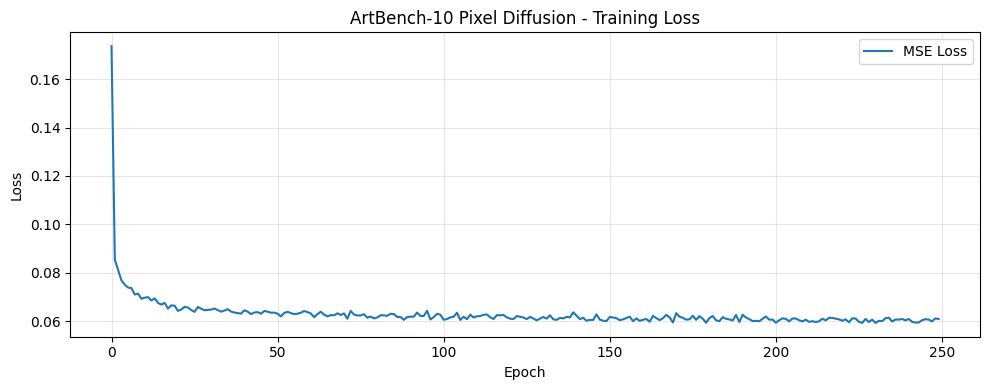

✅ Modelo salvo em runs/diffusion/artbench_pixel_diffusion.pt


In [31]:
# Train best model with best params from Optuna
# Uncomment the line below to use Optuna results automatically:
# best_params = study.best_params

# Using best known params :
best_lr = 0.000491
best_channels = 128
best_schedule_type = 'cosine'

best_pixel_model = PixelUNet(in_channels=3, model_channels=best_channels).to(device)
pixel_diffusion = GaussianDiffusion(num_timesteps=1000, beta_schedule=best_schedule_type, device=device)

history, _, pixel_ema = train_diffusion(
    best_pixel_model, artbench_train_loader, pixel_diffusion, 
    epochs=250, lr=best_lr, early_stopping=False, print_progress=True
)

# Use EMA model for sampling (better quality)
best_pixel_ema_model = pixel_ema.get_model()

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ArtBench-10 Pixel Diffusion - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save checkpoint
import os
os.makedirs('runs/diffusion', exist_ok=True)
torch.save({
    'model_state': best_pixel_model.state_dict(),
    'ema_state': best_pixel_ema_model.state_dict(),
    'params': {'model_channels': best_channels, 'lr': best_lr, 'beta_schedule': best_schedule_type},
    'history': history
}, 'runs/diffusion/artbench_pixel_diffusion.pt')
print(f"✅ Modelo salvo em runs/diffusion/artbench_pixel_diffusion.pt")



try:
    pass
    notify("✅ Finished successfully!")
except Exception as e:
    notify(f"❌ Failed: {traceback.format_exc()}", title="Notebook Error")

✅ EMA model loaded!
Params: {'model_channels': 128, 'lr': 0.000491, 'beta_schedule': 'cosine'}
Gerando amostras via DDIM (100 steps)...


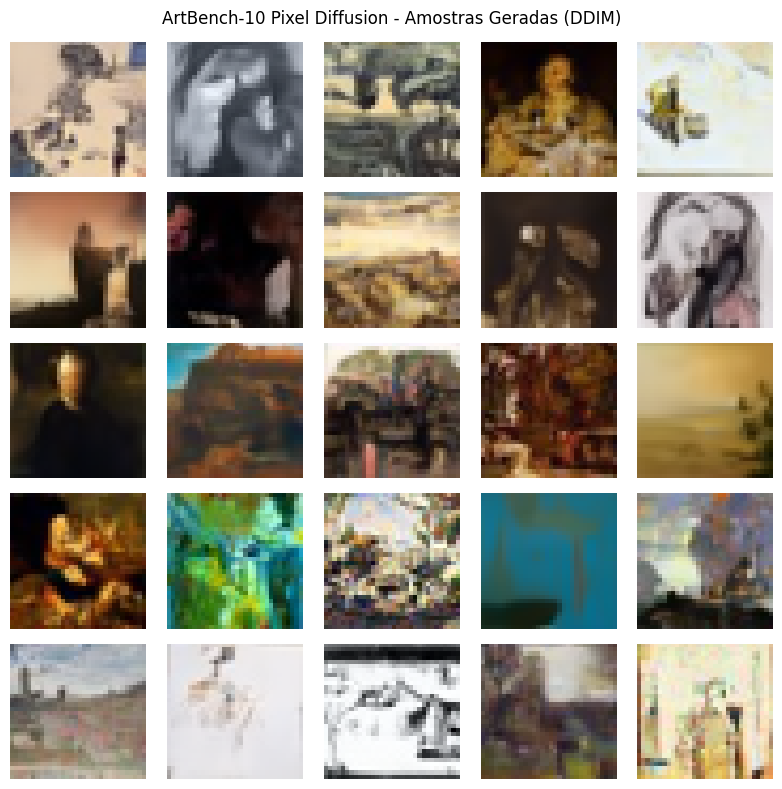


Interpolação entre dois pontos de ruído (DDIM, eta=0)...


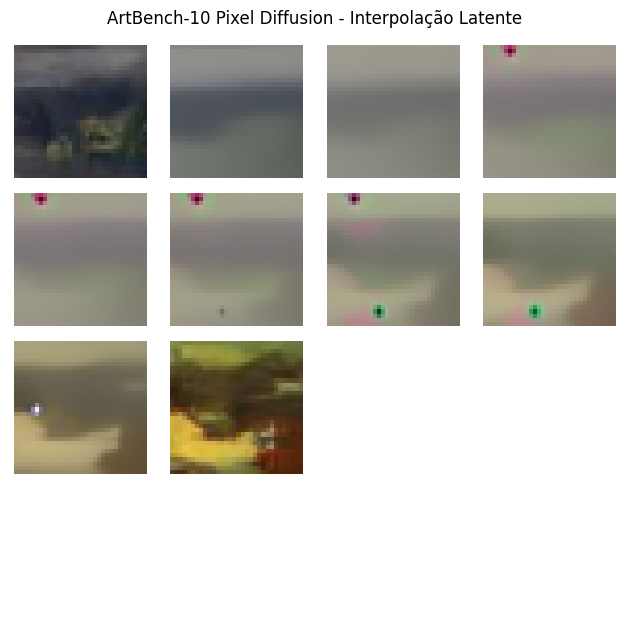

In [10]:
# ==========================================
# 1. CARREGANDO O MODELO TREINADO
# ==========================================
best_ckpt_path = Path('runs/diffusion/artbench_pixel_diffusion.pt')

if best_ckpt_path.exists():
    ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=True)
    loaded_params = ckpt['params']
    loaded_model = PixelUNet(in_channels=3, model_channels=loaded_params['model_channels']).to(device)
    
    
    # Prefer EMA weights if available (better sample quality)
    if 'ema_state' in ckpt:
        loaded_model.load_state_dict(ckpt['ema_state'])
        print("✅ EMA model loaded!")
    else:
        loaded_model.load_state_dict(ckpt['model_state'])
        print("✅ Model loaded (no EMA).")
    loaded_model.eval()
    
    beta_sched = loaded_params.get('beta_schedule', 'cosine')
    loaded_schedule = GaussianDiffusion(num_timesteps=1000, beta_schedule=beta_sched, device=device)
    print(f"Params: {loaded_params}")
else:
    print(f"❌ Checkpoint {best_ckpt_path} not found. Skipping inference.")
    loaded_model = None

# ==========================================
# 2. GERANDO AMOSTRAS (DDIM - faster)
# ==========================================
if loaded_model is not None:
    print("Gerando amostras via DDIM (100 steps)...")
    with torch.no_grad():
        samples = loaded_schedule.ddim_sample_loop(loaded_model, (25, 3, 32, 32), ddim_steps=100)
    show_image_grid(samples, channels=3, title='ArtBench-10 Pixel Diffusion - Amostras Geradas (DDIM)', n_show=25)

    # ==========================================
    # 3. INTERPOLAÇÃO NO ESPAÇO LATENTE (DDIM deterministic)
    # ==========================================
    print("\nInterpolação entre dois pontos de ruído (DDIM, eta=0)...")
    z1 = torch.randn(1, 3, 32, 32, device=device)
    z2 = torch.randn(1, 3, 32, 32, device=device)
    n_interp = 10
    interp_images = []

    for alpha_val in torch.linspace(0, 1, n_interp):
        z_interp = (1 - alpha_val) * z1 + alpha_val * z2
        with torch.no_grad():
            img = loaded_schedule.ddim_sample_loop(
                loaded_model, z_interp.shape, ddim_steps=100, eta=0.0, x_init=z_interp
            )
        interp_images.append(img)

    interp_grid = torch.cat(interp_images, dim=0)
    show_image_grid(interp_grid, channels=3, title='ArtBench-10 Pixel Diffusion - Interpolação Latente', n_show=n_interp)

In [11]:
@torch.no_grad()
def evaluate_metrics(model, schedule, dataloader, device, num_samples=5000, use_ddim=True, ddim_steps=100):
    model.eval()
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=100, subsets=50, normalize=True).to(device)

    # Real images
    print(f"Extracting features for {num_samples} real images...")
    count = 0
    with tqdm(total=num_samples, desc="Real Images", leave=False) as pbar:
        for real_imgs, _ in dataloader:
            if count >= num_samples: break
            batch = real_imgs[:num_samples-count].to(device)
            batch_01 = denorm(batch).clamp(0, 1)
            fid.update(batch_01, real=True)
            kid.update(batch_01, real=True)
            
            added = batch.size(0)
            count += added
            pbar.update(added)

    # Generated images
    sampler_name = f"DDIM ({ddim_steps} steps)" if use_ddim else "DDPM (1000 steps)"
    print(f"Generating {num_samples} fake images via {sampler_name}...")
    count = 0
    batch_size = 50
    with tqdm(total=num_samples, desc="Fake Images", leave=False) as pbar:
        while count < num_samples:
            current_bs = min(batch_size, num_samples - count)
            if use_ddim:
                fake_imgs = schedule.ddim_sample_loop(model, (current_bs, 3, 32, 32), ddim_steps=ddim_steps)
            else:
                fake_imgs = schedule.p_sample_loop(model, (current_bs, 3, 32, 32))
            fake_01 = denorm(fake_imgs).clamp(0, 1)
            fid.update(fake_01, real=False)
            kid.update(fake_01, real=False)
            
            count += current_bs
            pbar.update(current_bs)

    print("Computing final metrics...")
    return fid.compute().item(), kid.compute()[0].item()

def run_robust_evaluation(model, schedule, dataloader, device, num_runs=10, use_ddim=True, ddim_steps=100):
    fids, kids = [], []
    print(f"Starting robust evaluation ({num_runs} runs)...")
    for i in range(num_runs):
        print(f"\n--- Starting Run {i+1}/{num_runs} ---")
        set_seed(100 + i)
        f, k = evaluate_metrics(model, schedule, dataloader, device, use_ddim=use_ddim, ddim_steps=ddim_steps)
        fids.append(f)
        kids.append(k)
        print(f"Run {i+1}/{num_runs} Completed | FID: {f:.4f} | KID: {k:.4f}")
    
    print("\n" + "="*30)
    print(f"FINAL RESULTS ({num_runs} Runs):")
    print(f"FID: {np.mean(fids):.4f} ± {np.std(fids):.4f}")
    print(f"KID: {np.mean(kids):.4f} ± {np.std(kids):.4f}")
    print("="*30)

In [ ]:
ckpt_path = Path('runs/diffusion/artbench_pixel_diffusion.pt')
ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
params = ckpt['params']

eval_model = PixelUNet(in_channels=3, model_channels=params['model_channels']).to(device)
eval_model.load_state_dict(ckpt['ema_state'])
eval_model.eval()

pixel_diffusion = GaussianDiffusion(num_timesteps=1000, beta_schedule=params['beta_schedule'], device=device)

run_robust_evaluation(eval_model, pixel_diffusion, artbench_test_loader, device, use_ddim=True, ddim_steps=100)

NameError: name 'best_pixel_model' is not defined